# Batch Run Analysis

Load all `EpisodeRecord` pickles from a results folder and produce:

1. Distribution of cumulative profit across episodes
2. BET share per year (box plot across episodes)


In [1]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from fleet_replacement.episode import EpisodeRecord

REPO_ROOT = pathlib.Path.cwd().parent

sns.set_theme(style="whitegrid")

In [2]:
import matplotlib

# PGF output settings — pdflatex + serif fonts matching a typical LaTeX article
matplotlib.rcParams.update(
    {
        "pgf.texsystem": "pdflatex",
        "pgf.rcfonts": False,  # use LaTeX's own font, not matplotlib's
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "font.size": 10,
        "axes.labelsize": 7,
        "axes.titlesize": 8,
        "legend.fontsize": 6,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
    }
)

# Figures are saved here; create the directory if it doesn't exist
FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
print(f"PGF figures will be saved to: {FIGURES_DIR}")

PGF figures will be saved to: c:\git\KTH\fleet-replacement\figures


## Load batch results

Point `RESULTS_DIR` at the batch folder you want to analyse.  
All `episode_*.pkl` files in that folder are loaded automatically.


In [3]:
# ── Change this to the batch folder you want to analyse ──────────────────────
# RESULTS_DIR = REPO_ROOT / "results" / "important" / "batch_baseline_20260528_231106"
# RESULTS_DIR = REPO_ROOT / "results" / "important" / "batch_baseline_20260601_010719"
# RESULTS_DIR = REPO_ROOT / "results" / "important" / "batch_optimistic_20260529_005521"
# RESULTS_DIR = REPO_ROOT / "results" / "batch_env_myopic_20260608_145548"
RESULTS_DIR = REPO_ROOT / "results" / "batch_env_myopic_20260608_150001"
# ─────────────────────────────────────────────────────────────────────────────

pickle_files = sorted(RESULTS_DIR.glob("episode_*.pkl"))
records = [EpisodeRecord.load(str(f)) for f in pickle_files]

print(f"Loaded {len(records)} episodes from: {RESULTS_DIR.name}")
print(f"  Steps per episode : {records[0].n_steps}")
print(f"  Fleet size        : {records[0].fleet_size}")
print(f"  Years             : {records[0].years[0]} – {records[0].years[-1]}")

Loaded 1000 episodes from: batch_env_myopic_20260608_150001
  Steps per episode : 20
  Fleet size        : 8
  Years             : 2026 – 2045


In [4]:
# ── Change this to the batch folder you want to analyse ──────────────────────
# RESULTS_DIR = REPO_ROOT / "results" / "important" / "batch_baseline_20260528_231106"
# RESULTS_DIR = REPO_ROOT / "results" / "important" / "batch_baseline_20260601_010719"
# RESULTS_DIR = REPO_ROOT / "results" / "important" / "batch_optimistic_20260529_005521"
RESULTS_DIR = REPO_ROOT / "results" / "batch_env_myopic_20260609_134647"
# ─────────────────────────────────────────────────────────────────────────────

pickle_files = sorted(RESULTS_DIR.glob("episode_*.pkl"))
records2 = [EpisodeRecord.load(str(f)) for f in pickle_files]

print(f"Loaded {len(records)} episodes from: {RESULTS_DIR.name}")
print(f"  Steps per episode : {records[0].n_steps}")
print(f"  Fleet size        : {records[0].fleet_size}")
print(f"  Years             : {records[0].years[0]} – {records[0].years[-1]}")

Loaded 1000 episodes from: batch_env_myopic_20260609_134647
  Steps per episode : 20
  Fleet size        : 8
  Years             : 2026 – 2045


In [5]:
records_all = records + records2

## Figure 1 — Distribution of cumulative profit across episodes


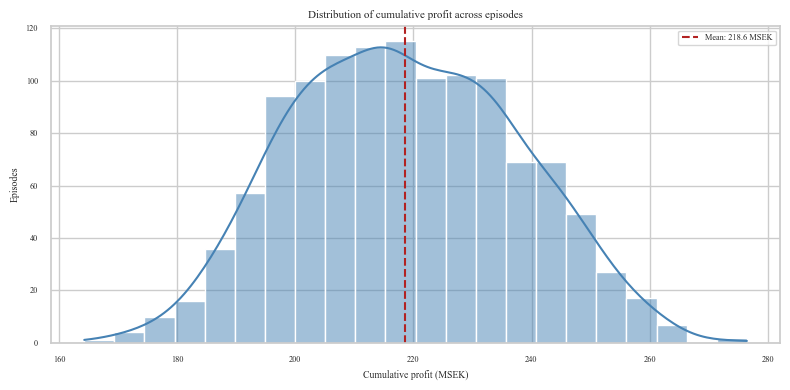

In [6]:
records = records_all[0:1200]
total_rewards = np.array([r.total_reward for r in records]) / 1e6  # MSEK

fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    total_rewards, binwidth=5, kde=True, ax=ax, color="steelblue", edgecolor="white"
)

ax.axvline(
    total_rewards.mean(),
    color="firebrick",
    linewidth=1.5,
    linestyle="--",
    label=f"Mean: {total_rewards.mean():.1f} MSEK",
)

ax.set_xlabel("Cumulative profit (MSEK)")
ax.set_ylabel("Episodes")
ax.set_title("Distribution of cumulative profit across episodes")
ax.legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig1_cumulative_profit.pgf", backend="pgf")
plt.show()

## Figure 2 — BET share per year (box plot across episodes)


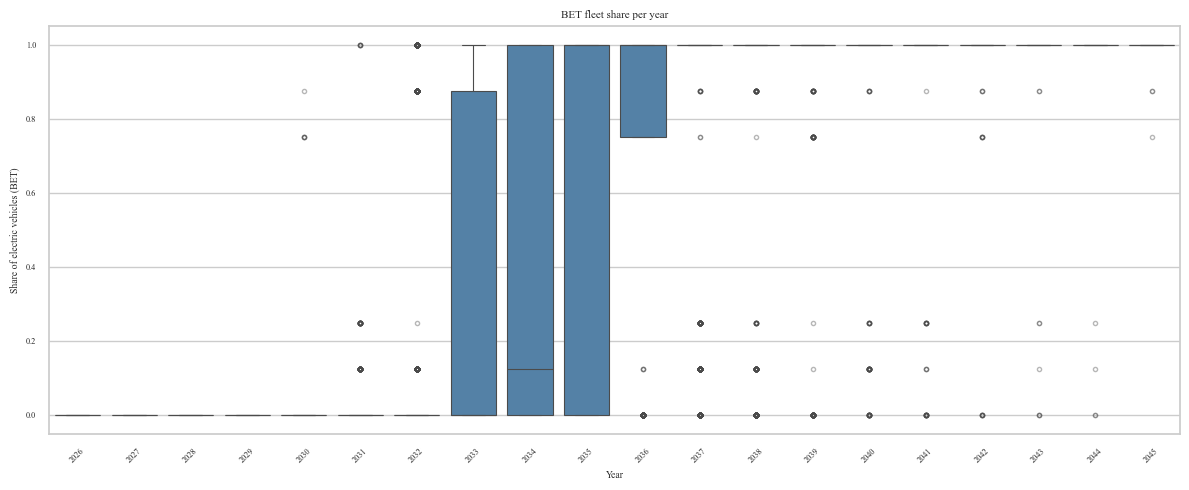

In [7]:
years = records[0].years

# Build long-form DataFrame: one row per (episode, year)
bet_share_long = pd.DataFrame(
    [
        {"year": year, "BET share": n_elec / r.fleet_size}
        for r in records
        for year, n_elec in zip(r.years, r.n_electric)
    ]
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.boxplot(
    data=bet_share_long,
    x="year",
    y="BET share",
    ax=ax,
    color="steelblue",
    linewidth=0.8,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
)

ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Year")
ax.set_ylabel("Share of electric vehicles (BET)")
ax.set_title("BET fleet share per year")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig2_bet_share.pgf", backend="pgf")
plt.show()

## Figure 3 — Explored uncertainty space

Each thin line is one episode's price trajectory. The shaded band spans the 25th–75th percentile across episodes and the solid line is the median. BET productivity is deterministic (logistic curve) so it is shown for reference only.


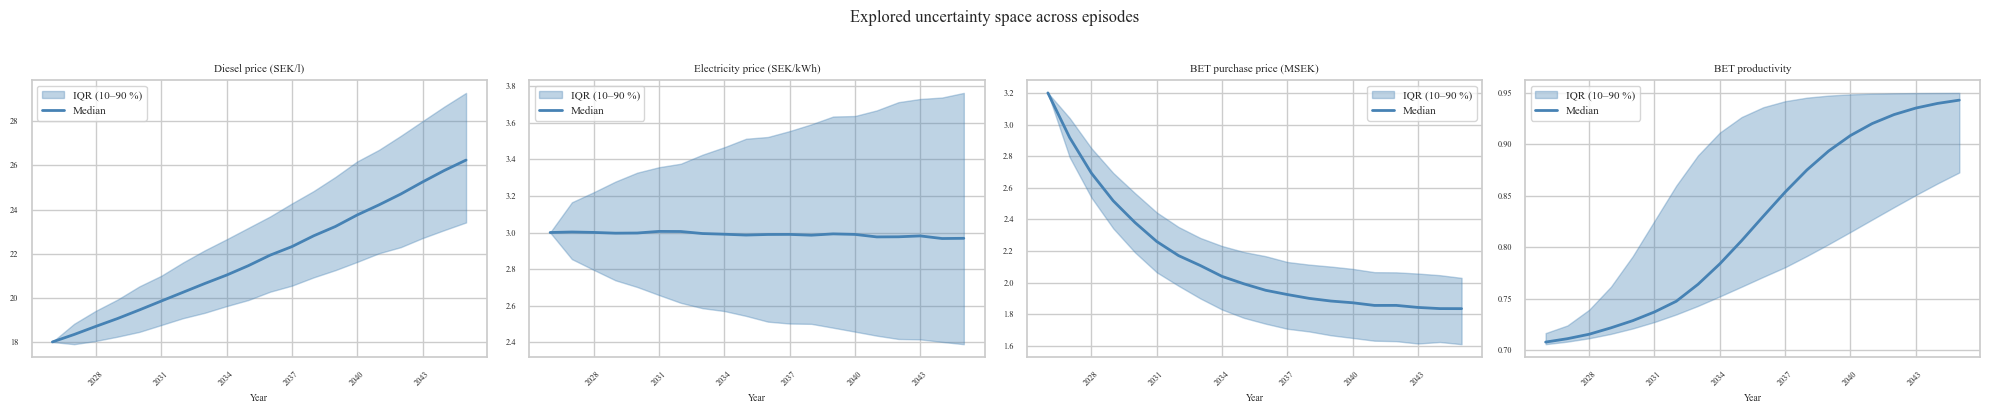

In [8]:
from matplotlib.ticker import MaxNLocator

_variables = {
    "Diesel price (SEK/l)": [r.energy_prices_diesel for r in records],
    "Electricity price (SEK/kWh)": [r.energy_prices_electricity for r in records],
    "BET purchase price (MSEK)": [r.purchase_prices_BET / 1e6 for r in records],
    "BET productivity": [r.productivities_BET for r in records],
}

years = records[0].years
n_cols = len(_variables)

fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), sharey=False)

for ax, (label, paths) in zip(axes, _variables.items()):
    mat = np.stack(paths)  # (n_episodes, n_steps)
    p10 = np.percentile(mat, 10, axis=0)
    p50 = np.percentile(mat, 50, axis=0)
    p90 = np.percentile(mat, 90, axis=0)

    # Individual episode trajectories
    # for row in mat:
    # ax.plot(years, row, color="steelblue", alpha=0.15, linewidth=0.7)

    # Median + IQR band
    ax.fill_between(
        years, p10, p90, color="steelblue", alpha=0.35, label="IQR (10–90 %)"
    )
    ax.plot(years, p50, color="steelblue", linewidth=2.0, label="Median")

    ax.set_title(label)
    ax.set_xlabel("Year")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)

fig.suptitle("Explored uncertainty space across episodes", y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig3_uncertainty_space.pgf", backend="pgf")
plt.show()

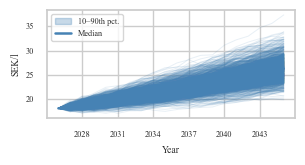

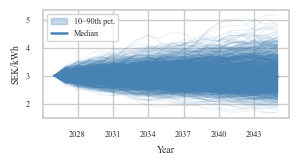

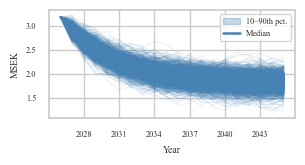

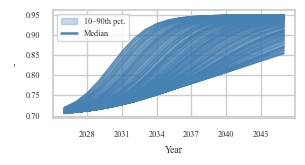

In [9]:
from matplotlib.ticker import MaxNLocator

# One figure per variable, sized for ~2x2 subfigures in a LaTeX document
# (textwidth = 468 pt => each panel is roughly half width)
panel_figsize = (3.15, 1.75)

uncertainty_panels = [
    (
        "SEK/l",
        [r.energy_prices_diesel for r in records],
        "uncertainty_diesel_price.pgf",
    ),
    (
        "SEK/kWh",
        [r.energy_prices_electricity for r in records],
        "uncertainty_electricity_price.pgf",
    ),
    (
        "MSEK",
        [r.purchase_prices_BET / 1e6 for r in records],
        "uncertainty_bet_purchase_price.pgf",
    ),
    (
        "-",
        [r.productivities_BET for r in records],
        "uncertainty_bet_productivity.pgf",
    ),
]

for ylabel, paths, filename in uncertainty_panels:
    mat = np.stack(paths)
    p10 = np.percentile(mat, 10, axis=0)
    p50 = np.percentile(mat, 50, axis=0)
    p90 = np.percentile(mat, 90, axis=0)

    fig, ax = plt.subplots(figsize=panel_figsize)

    for row in mat:
        ax.plot(years, row, color="steelblue", alpha=0.12, linewidth=0.7)

    ax.fill_between(
        years, p10, p90, color="steelblue", alpha=0.30, label="10–90th pct."
    )
    ax.plot(years, p50, color="steelblue", linewidth=1.8, label="Median")

    # ax.grid(False)
    ax.legend()
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / filename, backend="pgf", bbox_inches="tight")
    plt.show()

## Figure 4 — BET purchase price: uncertainty space + receding-horizon forecasts

This section compares the three lookahead strategies (`baseline`, `conservative`, `optimistic`).

- Thick line and shaded band: realised BET purchase-price uncertainty space across episodes (median + 10-90 percentile).
- Thin lines: reconstructed receding-horizon forecasts starting at each timestep's median information state (one forecast fan per timestep).

For now, forecasts are reconstructed from strategy configs and observed medians (stored episode artifacts do not currently include per-step forecast arrays).


In [27]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import yaml

from fleet_replacement.episode import EpisodeRecord
from fleet_replacement.policies.lookahead_model import (
    ForecastParams,
    InfoState,
    make_forecast,
)

REPO_ROOT = pathlib.Path.cwd().parent
FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

# Load BET productivity cap from full env config (fallback keeps the cell robust).
ENV_CONFIG_PATH = REPO_ROOT / "configs" / "env.yaml"
with ENV_CONFIG_PATH.open("r", encoding="utf-8") as f:
    _env_cfg = yaml.safe_load(f) or {}
BET_PRODUCTIVITY_MAX = float((_env_cfg.get("BET_productivity") or {}).get("max", 1.0))

# Three lookahead strategies from the same results set used in compare analysis
LOOKAHEAD_EXPERIMENTS = {
    "baseline": {
        "results_dir": REPO_ROOT
        / "results"
        / "important"
        / "2000"
        / "batch_env_lookahead_baseline_20260609_170434",
        "config_path": REPO_ROOT / "configs" / "lookahead_baseline.yaml",
        "color": "steelblue",
    },
    "conservative": {
        "results_dir": REPO_ROOT
        / "results"
        / "important"
        / "2000"
        / "batch_env_lookahead_conservative_20260609_170433",
        "config_path": REPO_ROOT / "configs" / "lookahead_conservative.yaml",
        "color": "darkorange",
    },
    "optimistic": {
        "results_dir": REPO_ROOT
        / "results"
        / "important"
        / "2000"
        / "batch_env_lookahead_optimistic_20260609_170433",
        "config_path": REPO_ROOT / "configs" / "lookahead_optimistic.yaml",
        "color": "seagreen",
    },
}


def _load_lookahead_from_partial_config(
    config_path: pathlib.Path,
) -> tuple[int, ForecastParams]:
    with config_path.open("r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f) or {}

    horizon = int(cfg.get("horizon", 1))
    rates = cfg.get("forecast_rates") or {}

    forecast_params = ForecastParams(
        diesel_price_growth=float(rates.get("diesel_price_growth", 0.0)),
        electricity_price_growth=float(rates.get("electricity_price_growth", 0.0)),
        purchase_price_growth_DT=float(rates.get("purchase_price_growth_DT", 0.0)),
        BET_price_gap_closure_rate=float(rates.get("BET_price_gap_closure_rate", 0.0)),
        BET_productivity_growth=float(rates.get("BET_productivity_growth", 0.0)),
    )
    return horizon, forecast_params


def _load_strategy_payload(name: str, spec: dict) -> dict:
    files = sorted(spec["results_dir"].glob("episode_*.pkl"))
    if not files:
        raise FileNotFoundError(
            f"No episode_*.pkl found for strategy '{name}': {spec['results_dir']}"
        )

    recs = [EpisodeRecord.load(str(f)) for f in files]
    horizon, forecast_params = _load_lookahead_from_partial_config(spec["config_path"])

    # Episode arrays: shape (n_episodes, n_steps)
    years = recs[0].years
    bet_mat = np.stack([r.purchase_prices_BET for r in recs], axis=0)
    dt_mat = np.stack([r.purchase_prices_DT for r in recs], axis=0)
    diesel_mat = np.stack([r.energy_prices_diesel for r in recs], axis=0)
    elec_mat = np.stack([r.energy_prices_electricity for r in recs], axis=0)
    prod_mat = np.stack([r.productivities_BET for r in recs], axis=0)

    # Realised uncertainty summaries
    bet_p0 = np.percentile(bet_mat, 0, axis=0)
    bet_p10 = np.percentile(bet_mat, 10, axis=0)
    bet_p25 = np.percentile(bet_mat, 25, axis=0)
    bet_p50 = np.percentile(bet_mat, 50, axis=0)
    bet_p75 = np.percentile(bet_mat, 75, axis=0)
    bet_p90 = np.percentile(bet_mat, 90, axis=0)
    bet_p100 = np.percentile(bet_mat, 100, axis=0)

    diesel_p0 = np.percentile(diesel_mat, 0, axis=0)
    diesel_p10 = np.percentile(diesel_mat, 10, axis=0)
    diesel_p25 = np.percentile(diesel_mat, 25, axis=0)
    diesel_p50 = np.percentile(diesel_mat, 50, axis=0)
    diesel_p75 = np.percentile(diesel_mat, 75, axis=0)
    diesel_p90 = np.percentile(diesel_mat, 90, axis=0)
    diesel_p100 = np.percentile(diesel_mat, 100, axis=0)

    # Median information state at each timestep (anchor for reconstructed forecast fans)
    med_dt = np.percentile(dt_mat, 50, axis=0)
    med_diesel = np.percentile(diesel_mat, 50, axis=0)
    med_elec = np.percentile(elec_mat, 50, axis=0)
    med_prod = np.percentile(prod_mat, 50, axis=0)

    # Receding-horizon forecasts from every timestep median start state
    bet_forecast_lines = []
    diesel_forecast_lines = []
    n_steps = len(years)
    for t in range(n_steps):
        info = InfoState(
            year=int(years[t]),
            energy_price_diesel=float(med_diesel[t]),
            energy_price_electricity=float(med_elec[t]),
            purchase_price_DT=float(med_dt[t]),
            purchase_price_BET=float(bet_p50[t]),
            productivity_BET=float(med_prod[t]),
        )
        fc = make_forecast(info, horizon, BET_PRODUCTIVITY_MAX, forecast_params)

        fc_years = int(years[t]) + np.arange(horizon)
        # Keep only forecast points that are on the observed timeline to avoid extrapolation artifacts
        end_year = int(years[-1])
        valid = fc_years <= end_year
        bet_forecast_lines.append((fc_years[valid], fc.purchase_price_BET[valid]))
        diesel_forecast_lines.append((fc_years[valid], fc.energy_price_diesel[valid]))

    return {
        "name": name,
        "records": recs,
        "years": years,
        "color": spec["color"],
        "horizon": horizon,
        "forecast_params": forecast_params,
        # Backward-compatible keys used by BET plotting cell
        "p10": bet_p10,
        "p50": bet_p50,
        "p90": bet_p90,
        "forecast_lines": bet_forecast_lines,
        # Explicit BET keys
        "bet_p0": bet_p0,
        "bet_p10": bet_p10,
        "bet_p25": bet_p25,
        "bet_p50": bet_p50,
        "bet_p75": bet_p75,
        "bet_p90": bet_p90,
        "bet_p100": bet_p100,
        "bet_forecast_lines": bet_forecast_lines,
        # Diesel keys for Figure 5
        "diesel_p0": diesel_p0,
        "diesel_p10": diesel_p10,
        "diesel_p25": diesel_p25,
        "diesel_p50": diesel_p50,
        "diesel_p75": diesel_p75,
        "diesel_p90": diesel_p90,
        "diesel_p100": diesel_p100,
        "diesel_forecast_lines": diesel_forecast_lines,
    }


strategy_payloads = {
    name: _load_strategy_payload(name, spec)
    for name, spec in LOOKAHEAD_EXPERIMENTS.items()
}

for name, payload in strategy_payloads.items():
    fp = payload["forecast_params"]
    print(
        f"{name:12s} episodes={len(payload['records']):4d} horizon={payload['horizon']:2d} "
        f"diesel_growth={fp.diesel_price_growth:.3f} BET_gap_closure={fp.BET_price_gap_closure_rate:.3f}"
    )

baseline     episodes=2000 horizon=10 diesel_growth=0.000 BET_gap_closure=0.000
conservative episodes=2000 horizon=10 diesel_growth=0.010 BET_gap_closure=0.020
optimistic   episodes=2000 horizon=10 diesel_growth=0.030 BET_gap_closure=0.050


Saved: c:\git\KTH\fleet-replacement\figures\uncertainty_bet_purchase_price_forecast_baseline.pgf


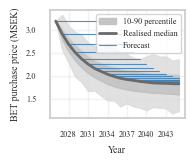

Saved: c:\git\KTH\fleet-replacement\figures\uncertainty_bet_purchase_price_forecast_conservative.pgf


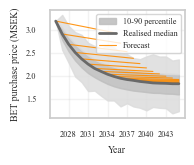

Saved: c:\git\KTH\fleet-replacement\figures\uncertainty_bet_purchase_price_forecast_optimistic.pgf


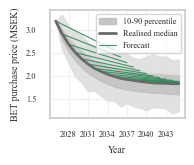

In [37]:
def plot_bet_uncertainty_with_forecasts(payload: dict, save: bool = True) -> None:
    from matplotlib.ticker import MaxNLocator

    years = payload["years"]
    color = payload["color"]

    # Sized for 3 side-by-side subfigures in a LaTeX row
    fig, ax = plt.subplots(figsize=(2.05, 1.75))

    # Two-tone uncertainty space: light grey tails (0-10, 90-100), dark grey middle (10-90)
    ax.fill_between(
        years,
        payload["bet_p0"] / 1e6,
        payload["bet_p10"] / 1e6,
        color="gainsboro",
        alpha=0.85,
        label="",
        zorder=1,
    )
    ax.fill_between(
        years,
        payload["bet_p10"] / 1e6,
        payload["bet_p90"] / 1e6,
        color="silver",
        alpha=0.9,
        label="10-90 percentile",
        zorder=1,
    )
    ax.fill_between(
        years,
        payload["bet_p90"] / 1e6,
        payload["bet_p100"] / 1e6,
        color="gainsboro",
        alpha=0.85,
        label="",
        zorder=1,
    )
    ax.plot(
        years,
        payload["bet_p50"] / 1e6,
        color="dimgray",
        linewidth=2.0,
        label="Realised median",
        zorder=3,
    )

    # Receding-horizon forecast fan (strategy color)
    for i, (fc_years, fc_bet) in enumerate(payload["forecast_lines"]):
        label = "Forecast" if i == 0 else None
        ax.plot(
            fc_years,
            fc_bet / 1e6,
            color=color,
            alpha=0.9,
            linewidth=0.8,
            label=label,
            zorder=2,
        )

    ax.set_xlabel("Year")
    ax.set_ylabel("BET purchase price (MSEK)")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis="x", rotation=0)
    ax.legend(loc="best")
    ax.grid(True, alpha=0.25)

    plt.tight_layout()

    if save:
        out_path = (
            FIGURES_DIR
            / f"uncertainty_bet_purchase_price_forecast_{payload['name']}.pgf"
        )
        fig.savefig(out_path, backend="pgf", bbox_inches="tight")
        print(f"Saved: {out_path}")

    plt.show()


for strategy_name in ["baseline", "conservative", "optimistic"]:
    plot_bet_uncertainty_with_forecasts(strategy_payloads[strategy_name], save=True)

In [13]:
# Spot check: forecast starts must match the realised median anchor at the selected timestep
strategy_name = "conservative"
check_t = 5

payload = strategy_payloads[strategy_name]
fc_years, fc_bet = payload["forecast_lines"][check_t]
anchor_year = int(payload["years"][check_t])
anchor_msek = payload["p50"][check_t] / 1e6

print(f"strategy={strategy_name}, t={check_t}, year={anchor_year}")
print(f"anchor (realised median): {anchor_msek:.4f} MSEK")
print(f"forecast[0]:             {fc_bet[0] / 1e6:.4f} MSEK")
print("first forecast points (MSEK):", np.round(fc_bet[: min(4, len(fc_bet))] / 1e6, 4))

strategy=conservative, t=5, year=2031
anchor (realised median): 2.2586 MSEK
forecast[0]:             2.2586 MSEK
first forecast points (MSEK): [2.2586 2.2495 2.2403 2.2311]


In [ ]:
# Spot check: diesel forecast starts must match the realised median anchor at the selected timestep
strategy_name = "conservative"
check_t = 5

payload = strategy_payloads[strategy_name]
fc_years, fc_diesel = payload["diesel_forecast_lines"][check_t]
anchor_year = int(payload["years"][check_t])
anchor_diesel = payload["diesel_p50"][check_t]

print(f"strategy={strategy_name}, t={check_t}, year={anchor_year}")
print(f"anchor (realised median): {anchor_diesel:.4f} SEK/l")
print(f"forecast[0]:             {fc_diesel[0]:.4f} SEK/l")
print(
    "first forecast points (SEK/l):", np.round(fc_diesel[: min(4, len(fc_diesel))], 4)
)

strategy=conservative, t=5, year=2031
anchor (realised median): 19.8709 SEK/l
forecast[0]:             19.8709 SEK/l
first forecast points (SEK/l): [19.8709 20.0696 20.2683 20.467 ]


Saved: c:\git\KTH\fleet-replacement\figures\uncertainty_diesel_price_forecast_baseline.pgf


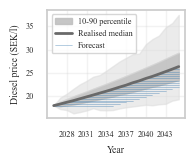

Saved: c:\git\KTH\fleet-replacement\figures\uncertainty_diesel_price_forecast_conservative.pgf


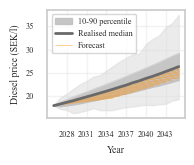

Saved: c:\git\KTH\fleet-replacement\figures\uncertainty_diesel_price_forecast_optimistic.pgf


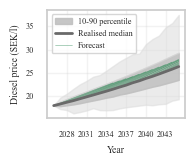

In [40]:
def plot_diesel_uncertainty_with_forecasts(payload: dict, save: bool = True) -> None:
    from matplotlib.ticker import MaxNLocator

    years = payload["years"]
    color = payload["color"]

    # Sized for 3 side-by-side subfigures in a LaTeX row
    fig, ax = plt.subplots(figsize=(2.05, 1.75))

    # Two-tone uncertainty space: light grey tails (0-10, 90-100), dark grey middle (10-90)
    ax.fill_between(
        years,
        payload["diesel_p0"],
        payload["diesel_p10"],
        color="gainsboro",
        alpha=0.55,
        # label="Realised 0-10 percentile",
        zorder=1,
    )
    ax.fill_between(
        years,
        payload["diesel_p10"],
        payload["diesel_p90"],
        color="silver",
        alpha=0.9,
        label="10-90 percentile",
        zorder=1,
    )
    ax.fill_between(
        years,
        payload["diesel_p90"],
        payload["diesel_p100"],
        color="gainsboro",
        alpha=0.55,
        # label="Realised 90-100 percentile",
        zorder=1,
    )
    ax.plot(
        years,
        payload["diesel_p50"],
        color="dimgray",
        linewidth=2.0,
        label="Realised median",
        zorder=3,
    )

    # Receding-horizon forecast fan (strategy color)
    for i, (fc_years, fc_diesel) in enumerate(payload["diesel_forecast_lines"]):
        label = "Forecast" if i == 0 else None
        ax.plot(
            fc_years,
            fc_diesel,
            color=color,
            alpha=0.7,
            linewidth=0.4,
            label=label,
            zorder=2,
        )

    ax.set_xlabel("Year")
    ax.set_ylabel("Diesel price (SEK/l)")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis="x", rotation=0)
    ax.legend(loc="best")
    ax.grid(True, alpha=0.25)

    plt.tight_layout()

    if save:
        out_path = (
            FIGURES_DIR / f"uncertainty_diesel_price_forecast_{payload['name']}.pgf"
        )
        fig.savefig(out_path, backend="pgf", bbox_inches="tight")
        print(f"Saved: {out_path}")

    plt.show()


for strategy_name in ["baseline", "conservative", "optimistic"]:
    plot_diesel_uncertainty_with_forecasts(strategy_payloads[strategy_name], save=True)

## Figure 5 — Diesel price: uncertainty space + receding-horizon forecasts

This section mirrors Figure 4 but for diesel price.

- Thick line and shaded band: realised diesel-price uncertainty space across episodes (median + 10-90 percentile).
- Thin lines: reconstructed receding-horizon diesel forecasts starting at each timestep's median information state.
